<a href="https://colab.research.google.com/github/luiggijuarez/challenge-telecom-x-2-churn-analysis/blob/main/TelecomX_2_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importación de Librerías y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Librerías de Machine Learning
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Carga de datos
df = pd.read_csv('/content/drive/MyDrive/datos_tratados.csv')

In [7]:
# Limpieza inicial: eliminamos ID y filas sin target
df = df.drop(columns=['customerID'])
df = df.dropna(subset=['Churn'])

In [8]:
print("Datos cargados y limpios. Dimensiones:", df.shape)
df.head()

Datos cargados y limpios. Dimensiones: (7043, 20)


,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Contract,account.PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0.0,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,1.0,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


Análisis de Correlación y Visualización

In [9]:
# Ver proporción de Churn
print("Proporción de Clases:")
print(df['Churn'].value_counts(normalize=True))

Proporción de Clases:
Churn
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64


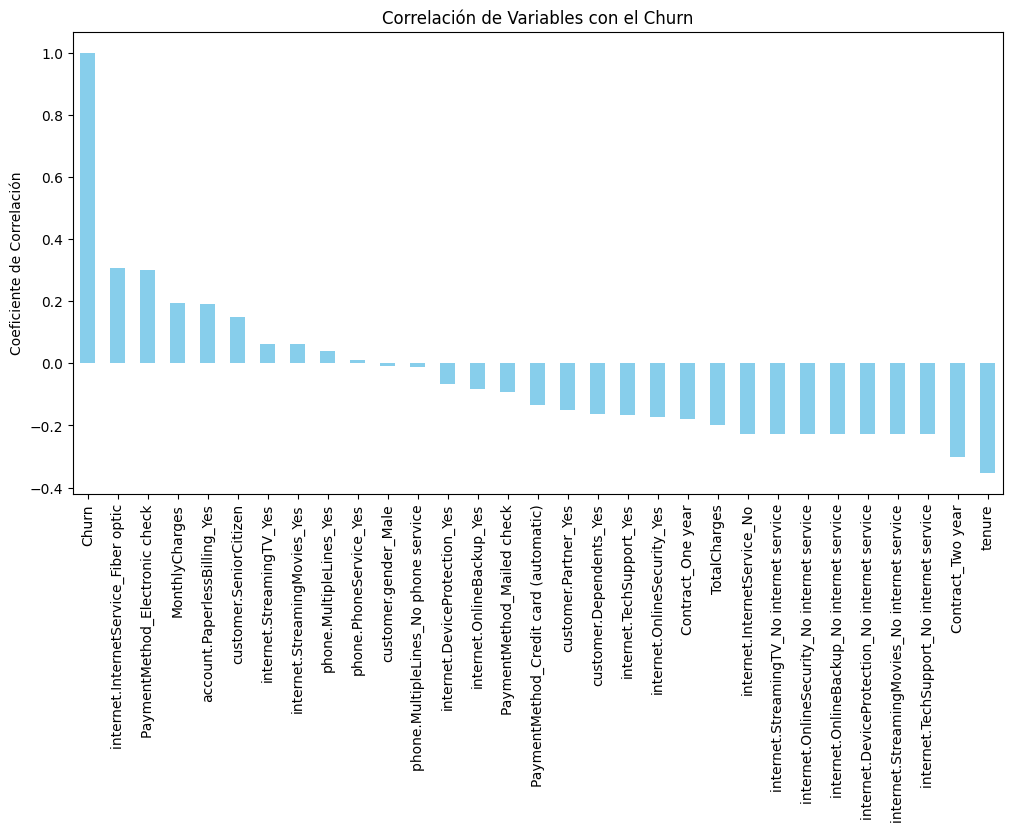

In [10]:
# Matriz de Correlación rápida (usando dummies para incluir categóricas)
plt.figure(figsize=(12, 6))
df_dummies = pd.get_dummies(df, drop_first=True)
df_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Correlación de Variables con el Churn')
plt.ylabel('Coeficiente de Correlación')
plt.show()

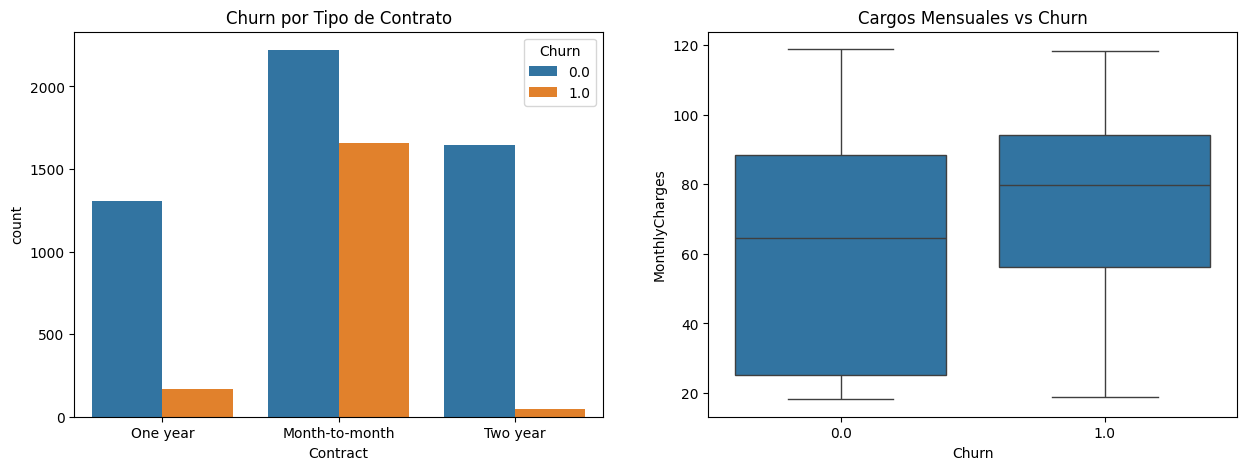

In [11]:
# Análisis Dirigido: Contrato y Cargos
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=df, x='Contract', hue='Churn', ax=ax[0])
ax[0].set_title('Churn por Tipo de Contrato')
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax[1])
ax[1].set_title('Cargos Mensuales vs Churn')
plt.show()

Preprocesamiento y Creación de Modelos

In [12]:
# Separación de variables
X = df.drop('Churn', axis=1)
y = df['Churn']

In [13]:
# Identificar tipos de columnas
numericas = X.select_dtypes(exclude=['object']).columns.tolist()
categoricas = X.select_dtypes(include=['object']).columns.tolist()

In [14]:
# Crear el transformador
preprocesador = make_column_transformer(
    (StandardScaler(), numericas),
    (OneHotEncoder(handle_unknown='ignore'), categoricas)
)

In [15]:
# División Estratificada (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [16]:
# Definir los modelos a comparar
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(max_depth=5, random_state=42)
}

Entrenamiento y Evaluación (Métricas)


MODELO: Regresión Logística
Accuracy CV: 0.8069
Recall CV: 0.5572
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1035
         1.0       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



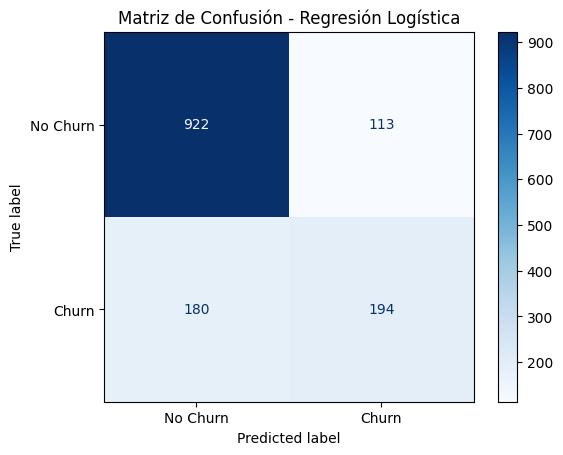


MODELO: Random Forest
Accuracy CV: 0.7964
Recall CV: 0.4341
              precision    recall  f1-score   support

         0.0       0.81      0.92      0.86      1035
         1.0       0.65      0.42      0.51       374

    accuracy                           0.78      1409
   macro avg       0.73      0.67      0.68      1409
weighted avg       0.77      0.78      0.77      1409



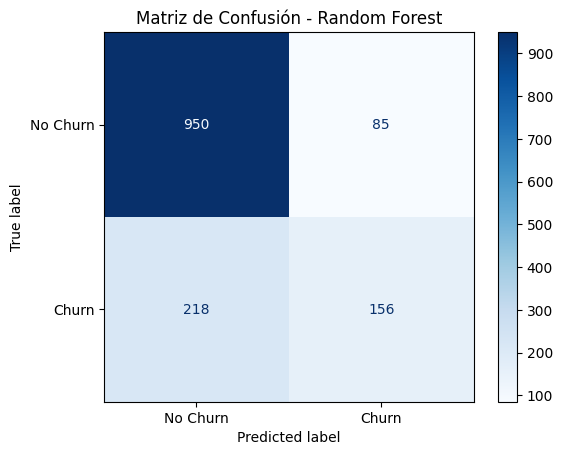

In [17]:
for nombre, modelo in modelos.items():
    # Crear Pipeline
    pipeline = make_pipeline(preprocesador, modelo)

    # Validación Cruzada
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=['accuracy', 'recall', 'f1'])

    # Entrenamiento final y predicción
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print(f"\n{'='*30}\nMODELO: {nombre}\n{'='*30}")
    print(f"Accuracy CV: {cv_results['test_accuracy'].mean():.4f}")
    print(f"Recall CV: {cv_results['test_recall'].mean():.4f}")
    print(classification_report(y_test, y_pred))

    # Matriz de Confusión
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Churn', 'Churn'], cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.show()

Importancia de las Variables e Insights Finales

/tmp/ipykernel_420/1935760538.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancia.head(10), x='Importancia', y='Variable', palette='viridis')


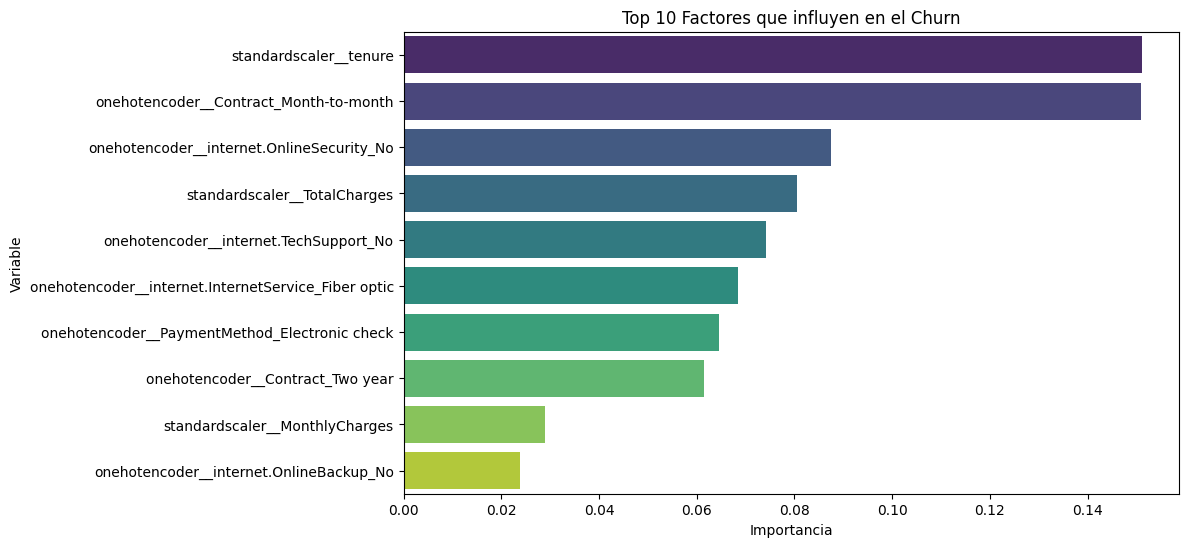

Variables críticas identificadas:
                                     Variable  Importancia
1                      standardscaler__tenure     0.151036
36     onehotencoder__Contract_Month-to-month     0.150862
18  onehotencoder__internet.OnlineSecurity_No     0.087553


In [18]:
# Extraer importancia del Random Forest
rf_pipeline = make_pipeline(preprocesador, modelos['Random Forest'])
rf_pipeline.fit(X_train, y_train)

importancias = rf_pipeline.named_steps['randomforestclassifier'].feature_importances_
nombres_features = rf_pipeline.named_steps['columntransformer'].get_feature_names_out()

df_importancia = pd.DataFrame({'Variable': nombres_features, 'Importancia': importancias}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancia.head(10), x='Importancia', y='Variable', palette='viridis')
plt.title('Top 10 Factores que influyen en el Churn')
plt.show()

print("Variables críticas identificadas:")
print(df_importancia.head(3))